# Notebook 03: Power Analysis

## Research question

What effect sizes could this experimental design detect with adequate probability, and how should those calculations inform future sample-size planning?

## Analytical objective

Compute the minimum detectable effect (MDE) at α = 0.05 and 80% power, evaluate the relationship between effect size and power, and quantify the sample size required for smaller effects.

## Statistical framework

The calculations use normal-approximation planning formulas with the observed group sizes and variances. Treat the resulting MDEs as planning approximations, not as estimates of the true treatment effect.

## Required output

Complete the TODO cells, report MDEs in both absolute and relative units, compare raw and winsorized spend, and state the sample-size implication for a business-relevant target effect.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
hillstrom_df = pd.read_csv("../data/raw/hillstrom.csv")

hillstrom_df

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web,Mens E-Mail,0,0,0.0
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone,Mens E-Mail,0,0,0.0
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone,Mens E-Mail,0,0,0.0
63998,1,5) $500 - $750,552.94,1,0,Surburban,1,Multichannel,Womens E-Mail,0,0,0.0


## MDE for visit rate, conversion rate, and spend

For each pairwise comparison, the notebook estimates the standard error at the observed sample size and multiplies it by `z_alpha + z_beta` (approximately 1.96 + 0.84). This gives an 80%-power planning approximation.

In [3]:
# TODO: Calculate the MDE for visit rate for each pairwise comparison.
# Assumptions: alpha=0.05, power=0.80, z_alpha=1.96, z_beta=0.84.
# Hint: MDE = sqrt(p1(1-p1)/n1 + p2(1-p2)/n2) * (z_alpha + z_beta).

comparisons = [("Mens E-Mail", "No E-Mail"), ("Mens E-Mail", "Womens E-Mail"), ("Womens E-Mail", "No E-Mail")]
alpha, power = 0.05, 0.80
z_alpha, z_beta = 1.96, 0.84

visit_counts_df = hillstrom_df.groupby("segment")["visit"].agg(["sum", "count"])

for group1, group2 in comparisons:
    sum1 = visit_counts_df.loc[group1, "sum"]
    n1 = visit_counts_df.loc[group1, "count"]
    sum2 = visit_counts_df.loc[group2, "sum"]
    n2 = visit_counts_df.loc[group2, "count"]

    p1, p2 = sum1 / n1, sum2 / n2
    MDE = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2) * (z_alpha + z_beta)
    print(f"MDE for {group1} vs {group2}: {MDE:.4f}")
    

MDE for Mens E-Mail vs No E-Mail: 0.0095
MDE for Mens E-Mail vs Womens E-Mail: 0.0101
MDE for Womens E-Mail vs No E-Mail: 0.0091


In [4]:
# TODO: Repeat the MDE calculation for conversion rate.

conversion_counts_df = hillstrom_df.groupby("segment")["conversion"].agg(["sum", "count"])

for group1, group2 in comparisons:
    sum1 = conversion_counts_df.loc[group1, "sum"]
    n1 = conversion_counts_df.loc[group1, "count"]
    sum2 = conversion_counts_df.loc[group2, "sum"]
    n2 = conversion_counts_df.loc[group2, "count"]

    p1, p2 = sum1 / n1, sum2 / n2
    MDE = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2) * (z_alpha + z_beta)
    print(f"MDE for {group1} vs {group2}: {MDE:.4f}")


MDE for Mens E-Mail vs No E-Mail: 0.0026
MDE for Mens E-Mail vs Womens E-Mail: 0.0028
MDE for Womens E-Mail vs No E-Mail: 0.0023


In [7]:
# TODO: Calculate the spend MDE using the Welch-style standard error.
spend_count_df = hillstrom_df.groupby("segment")["spend"]
for group1, group2 in comparisons:
    group1_data = spend_count_df.get_group(group1)
    group2_data = spend_count_df.get_group(group2)
    group1_mean, group1_std, n1 = group1_data.mean(), group1_data.std(), len(group1_data)
    group2_mean, group2_std, n2 = group2_data.mean(), group2_data.std(), len(group2_data)
    se = (group1_std ** 2 / n1 + group2_std ** 2 / n2) ** 0.5
    MDE = se * (z_alpha + z_beta)
    print(f"MDE for {group1} vs {group2}: {MDE:.4f}")

MDE for Mens E-Mail vs No E-Mail: 0.4067
MDE for Mens E-Mail vs Womens E-Mail: 0.4469
MDE for Womens E-Mail vs No E-Mail: 0.3649


## Power curves

Each curve answers: if the true effect were this large, how often would a test reject the null? The horizontal 0.8 line marks the target power and the vertical marker identifies the MDE.

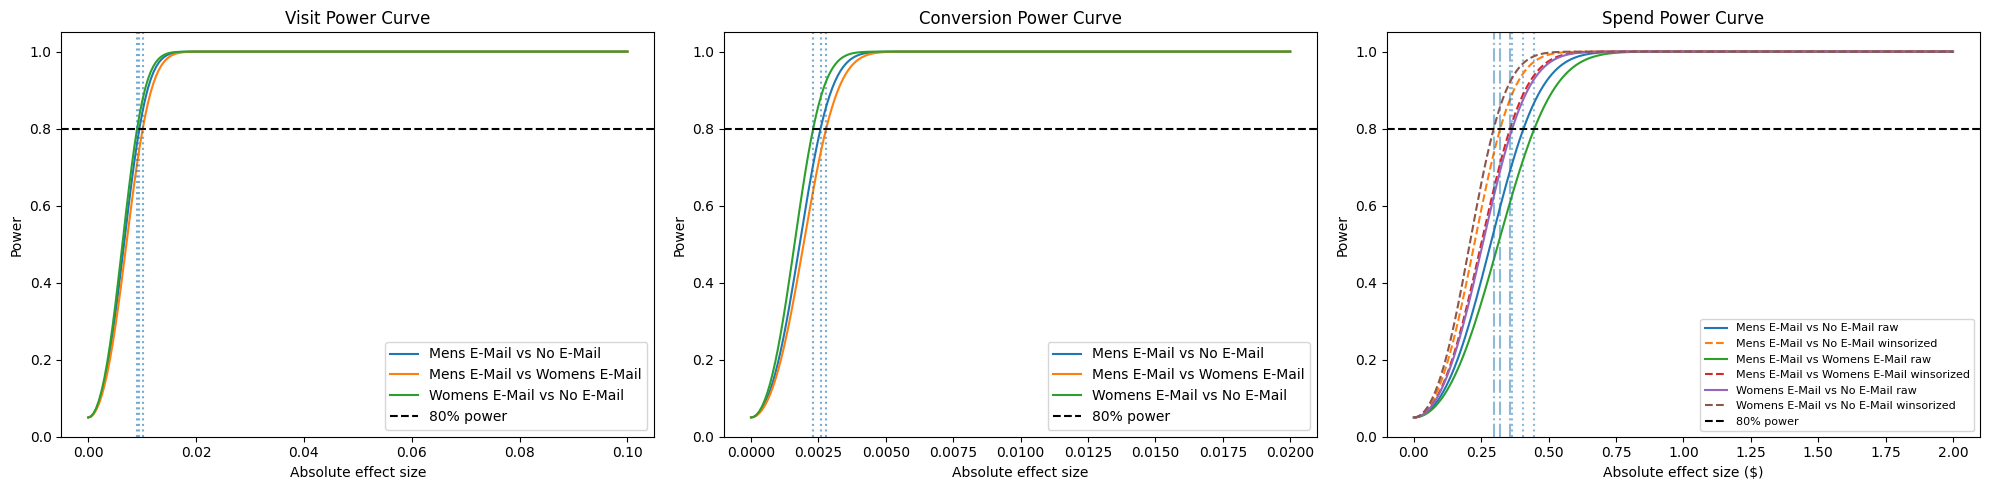

In [ ]:
# TODO: Build power curves for Visit, Conversion, and Spend.
# For each metric, create a grid of effect sizes and calculate rejection
# probability. For Spend, add a second curve after 99.9th-percentile
# winsorization. Mark the 80% power line and each MDE.
def calculate_mde_from_se(se, z_alpha, z_beta):
    return se * (z_alpha + z_beta)


def calculate_power(effect_sizes, se, z_alpha):
    effect_sizes = np.asarray(effect_sizes)
    noncentrality = effect_sizes / se

    power = (
        stats.norm.cdf(noncentrality - z_alpha)
        + stats.norm.cdf(-noncentrality - z_alpha)
    )

    return power


visit_grid = np.linspace(0, 0.10, 200)
conversion_grid = np.linspace(0, 0.02, 200)
spend_grid = np.linspace(0, 2.00, 200)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ============================================================
# 1. Visit power curves
# ============================================================

visit_stats = hillstrom_df.groupby("segment")["visit"].agg(
    mean="mean",
    count="count"
)

for i, (group1, group2) in enumerate(comparisons):
    p1 = visit_stats.loc[group1, "mean"]
    n1 = visit_stats.loc[group1, "count"]

    p2 = visit_stats.loc[group2, "mean"]
    n2 = visit_stats.loc[group2, "count"]

    se = np.sqrt(
        p1 * (1 - p1) / n1
        + p2 * (1 - p2) / n2
    )

    mde = calculate_mde_from_se(se, z_alpha, z_beta)
    power = calculate_power(visit_grid, se, z_alpha)

    axes[0].plot(
        visit_grid,
        power,
        label=f"{group1} vs {group2}"
    )

    axes[0].axvline(
        mde,
        linestyle=":",
        alpha=0.6
    )

axes[0].axhline(
    0.80,
    color="black",
    linestyle="--",
    label="80% power"
)

axes[0].set_title("Visit Power Curve")
axes[0].set_xlabel("Absolute effect size")
axes[0].set_ylabel("Power")
axes[0].set_ylim(0, 1.05)
axes[0].legend()


# ============================================================
# 2. Conversion power curves
# ============================================================

conversion_stats = hillstrom_df.groupby("segment")["conversion"].agg(
    mean="mean",
    count="count"
)

for group1, group2 in comparisons:
    p1 = conversion_stats.loc[group1, "mean"]
    n1 = conversion_stats.loc[group1, "count"]

    p2 = conversion_stats.loc[group2, "mean"]
    n2 = conversion_stats.loc[group2, "count"]

    se = np.sqrt(
        p1 * (1 - p1) / n1
        + p2 * (1 - p2) / n2
    )

    mde = calculate_mde_from_se(se, z_alpha, z_beta)
    power = calculate_power(conversion_grid, se, z_alpha)

    axes[1].plot(
        conversion_grid,
        power,
        label=f"{group1} vs {group2}"
    )

    axes[1].axvline(
        mde,
        linestyle=":",
        alpha=0.6
    )

axes[1].axhline(
    0.80,
    color="black",
    linestyle="--",
    label="80% power"
)

axes[1].set_title("Conversion Power Curve")
axes[1].set_xlabel("Absolute effect size")
axes[1].set_ylabel("Power")
axes[1].set_ylim(0, 1.05)
axes[1].legend()


# ============================================================
# 3. Spend power curves: raw vs winsorized
# ============================================================

spend_stats = hillstrom_df.groupby("segment")["spend"].agg(
    var="var",
    count="count"
)

spend_cap = hillstrom_df["spend"].quantile(0.999)

winsorized_df = hillstrom_df.copy()
winsorized_df["spend"] = winsorized_df["spend"].clip(
    upper=spend_cap
)

winsorized_stats = winsorized_df.groupby("segment")["spend"].agg(
    var="var",
    count="count"
)

for group1, group2 in comparisons:
    n1 = spend_stats.loc[group1, "count"]
    n2 = spend_stats.loc[group2, "count"]

    # Raw spend
    raw_se = np.sqrt(
        spend_stats.loc[group1, "var"] / n1
        + spend_stats.loc[group2, "var"] / n2
    )

    raw_mde = calculate_mde_from_se(
        raw_se,
        z_alpha,
        z_beta
    )

    raw_power = calculate_power(
        spend_grid,
        raw_se,
        z_alpha
    )

    axes[2].plot(
        spend_grid,
        raw_power,
        label=f"{group1} vs {group2} raw"
    )

    axes[2].axvline(
        raw_mde,
        linestyle=":",
        alpha=0.5
    )

    # Winsorized spend
    winsor_se = np.sqrt(
        winsorized_stats.loc[group1, "var"] / n1
        + winsorized_stats.loc[group2, "var"] / n2
    )

    winsor_mde = calculate_mde_from_se(
        winsor_se,
        z_alpha,
        z_beta
    )

    winsor_power = calculate_power(
        spend_grid,
        winsor_se,
        z_alpha
    )

    axes[2].plot(
        spend_grid,
        winsor_power,
        linestyle="--",
        label=f"{group1} vs {group2} winsorized"
    )

    axes[2].axvline(
        winsor_mde,
        linestyle="-.",
        alpha=0.5
    )

axes[2].axhline(
    0.80,
    color="black",
    linestyle="--",
    label="80% power"
)

axes[2].set_title("Spend Power Curve")
axes[2].set_xlabel("Absolute effect size ($)")
axes[2].set_ylabel("Power")
axes[2].set_ylim(0, 1.05)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()



## Sample size curves

The curves make the planning trade-off explicit. To detect a smaller effect, the required sample rises quickly because `n` is approximately proportional to `1 / MDE²`.

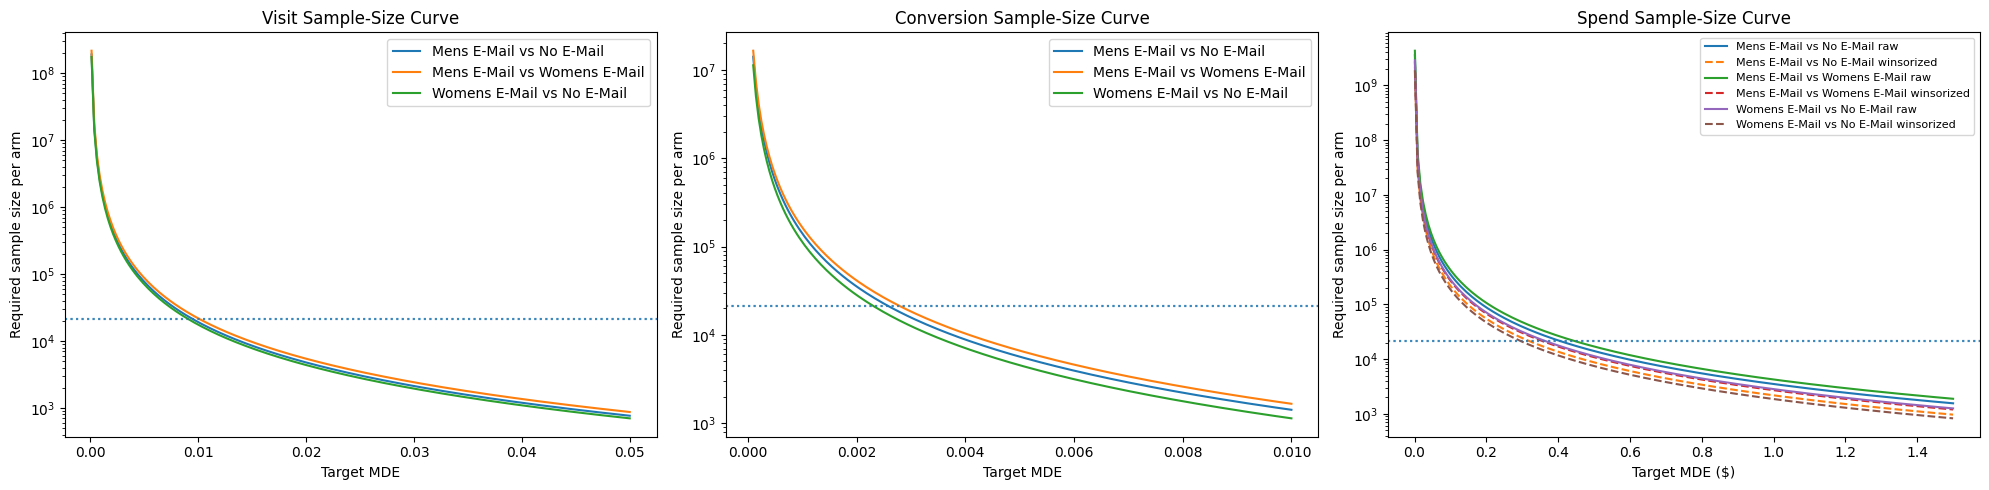

In [9]:
# TODO: Build sample-size curves for the three metrics.
# Use n = 2 * variance * (z_alpha + z_beta)^2 / MDE^2 and mark the observed
# sample size per arm. What happens as the target MDE gets smaller?
def required_sample_size(mde_grid, variance, z_alpha, z_beta):
    mde_grid = np.asarray(mde_grid)

    return (
        2
        * variance
        * (z_alpha + z_beta) ** 2
        / mde_grid ** 2
    )

visit_mde_grid = np.linspace(0.0001, 0.05, 200)
conversion_mde_grid = np.linspace(0.0001, 0.01, 200)
spend_mde_grid = np.linspace(0.001, 1.50, 200)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))


# ============================================================
# 1. Visit sample-size curves
# ============================================================

visit_stats = hillstrom_df.groupby("segment")["visit"].agg(
    mean="mean",
    count="count"
)

for group1, group2 in comparisons:
    p1 = visit_stats.loc[group1, "mean"]
    p2 = visit_stats.loc[group2, "mean"]

    n1 = visit_stats.loc[group1, "count"]
    n2 = visit_stats.loc[group2, "count"]

    variance = (
        p1 * (1 - p1)
        + p2 * (1 - p2)
    ) / 2

    required_n = required_sample_size(
        visit_mde_grid,
        variance,
        z_alpha,
        z_beta
    )

    observed_n_per_arm = (n1 + n2) / 2

    axes[0].plot(
        visit_mde_grid,
        required_n,
        label=f"{group1} vs {group2}"
    )

    axes[0].axhline(
        observed_n_per_arm,
        linestyle=":",
        alpha=0.5
    )

axes[0].set_title("Visit Sample-Size Curve")
axes[0].set_xlabel("Target MDE")
axes[0].set_ylabel("Required sample size per arm")
axes[0].set_yscale("log")
axes[0].legend()


# ============================================================
# 2. Conversion sample-size curves
# ============================================================

conversion_stats = hillstrom_df.groupby("segment")["conversion"].agg(
    mean="mean",
    count="count"
)

for group1, group2 in comparisons:
    p1 = conversion_stats.loc[group1, "mean"]
    p2 = conversion_stats.loc[group2, "mean"]

    n1 = conversion_stats.loc[group1, "count"]
    n2 = conversion_stats.loc[group2, "count"]

    variance = (
        p1 * (1 - p1)
        + p2 * (1 - p2)
    ) / 2

    required_n = required_sample_size(
        conversion_mde_grid,
        variance,
        z_alpha,
        z_beta
    )

    observed_n_per_arm = (n1 + n2) / 2

    axes[1].plot(
        conversion_mde_grid,
        required_n,
        label=f"{group1} vs {group2}"
    )

    axes[1].axhline(
        observed_n_per_arm,
        linestyle=":",
        alpha=0.5
    )

axes[1].set_title("Conversion Sample-Size Curve")
axes[1].set_xlabel("Target MDE")
axes[1].set_ylabel("Required sample size per arm")
axes[1].set_yscale("log")
axes[1].legend()


# ============================================================
# 3. Spend sample-size curves
# ============================================================

spend_stats = hillstrom_df.groupby("segment")["spend"].agg(
    var="var",
    count="count"
)

# Winsorized spend
spend_cap = hillstrom_df["spend"].quantile(0.999)

winsorized_df = hillstrom_df.copy()
winsorized_df["spend"] = winsorized_df["spend"].clip(
    upper=spend_cap
)

winsorized_stats = winsorized_df.groupby("segment")["spend"].agg(
    var="var",
    count="count"
)

for group1, group2 in comparisons:
    var1 = spend_stats.loc[group1, "var"]
    var2 = spend_stats.loc[group2, "var"]

    n1 = spend_stats.loc[group1, "count"]
    n2 = spend_stats.loc[group2, "count"]

    # 原始 spend 的平均方差
    raw_variance = (var1 + var2) / 2

    raw_required_n = required_sample_size(
        spend_mde_grid,
        raw_variance,
        z_alpha,
        z_beta
    )

    axes[2].plot(
        spend_mde_grid,
        raw_required_n,
        label=f"{group1} vs {group2} raw"
    )

    # Winsorized spend 的平均方差
    winsor_var1 = winsorized_stats.loc[group1, "var"]
    winsor_var2 = winsorized_stats.loc[group2, "var"]

    winsor_variance = (
        winsor_var1 + winsor_var2
    ) / 2

    winsor_required_n = required_sample_size(
        spend_mde_grid,
        winsor_variance,
        z_alpha,
        z_beta
    )

    axes[2].plot(
        spend_mde_grid,
        winsor_required_n,
        linestyle="--",
        label=f"{group1} vs {group2} winsorized"
    )

    observed_n_per_arm = (n1 + n2) / 2

    axes[2].axhline(
        observed_n_per_arm,
        linestyle=":",
        alpha=0.5
    )

axes[2].set_title("Spend Sample-Size Curve")
axes[2].set_xlabel("Target MDE ($)")
axes[2].set_ylabel("Required sample size per arm")
axes[2].set_yscale("log")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Express the MDE as a relative lift

Absolute percentage points can be misleading across metrics with different baselines. Dividing the MDE by the control-group baseline shows how large the improvement must be relative to current performance.

In [10]:
# TODO: Divide each MDE by the control-group baseline to report the
# relative lift required for 80% power.
def calculate_relative_mde(mde, control_baseline):
    return mde / control_baseline


visit_stats = hillstrom_df.groupby("segment")["visit"].agg(
    mean="mean",
    count="count"
)

conversion_stats = hillstrom_df.groupby("segment")["conversion"].agg(
    mean="mean",
    count="count"
)

spend_stats = hillstrom_df.groupby("segment")["spend"].agg(
    mean="mean",
    var="var",
    count="count"
)


for group1, group2 in comparisons:
    # group2 作为 baseline / control
    visit_p1 = visit_stats.loc[group1, "mean"]
    visit_p2 = visit_stats.loc[group2, "mean"]
    visit_n1 = visit_stats.loc[group1, "count"]
    visit_n2 = visit_stats.loc[group2, "count"]

    visit_se = np.sqrt(
        visit_p1 * (1 - visit_p1) / visit_n1
        + visit_p2 * (1 - visit_p2) / visit_n2
    )

    visit_mde = visit_se * (z_alpha + z_beta)
    visit_relative_mde = visit_mde / visit_p2


    conversion_p1 = conversion_stats.loc[group1, "mean"]
    conversion_p2 = conversion_stats.loc[group2, "mean"]
    conversion_n1 = conversion_stats.loc[group1, "count"]
    conversion_n2 = conversion_stats.loc[group2, "count"]

    conversion_se = np.sqrt(
        conversion_p1 * (1 - conversion_p1) / conversion_n1
        + conversion_p2 * (1 - conversion_p2) / conversion_n2
    )

    conversion_mde = conversion_se * (z_alpha + z_beta)
    conversion_relative_mde = conversion_mde / conversion_p2


    spend_mean2 = spend_stats.loc[group2, "mean"]
    spend_var1 = spend_stats.loc[group1, "var"]
    spend_var2 = spend_stats.loc[group2, "var"]
    spend_n1 = spend_stats.loc[group1, "count"]
    spend_n2 = spend_stats.loc[group2, "count"]

    spend_se = np.sqrt(
        spend_var1 / spend_n1
        + spend_var2 / spend_n2
    )

    spend_mde = spend_se * (z_alpha + z_beta)
    spend_relative_mde = spend_mde / spend_mean2


    print(f"\n{group1} vs {group2}")
    print(
        f"Visit: absolute MDE = {visit_mde:.4f}, "
        f"relative lift = {visit_relative_mde:.2%}"
    )
    print(
        f"Conversion: absolute MDE = {conversion_mde:.4f}, "
        f"relative lift = {conversion_relative_mde:.2%}"
    )
    print(
        f"Spend: absolute MDE = ${spend_mde:.4f}, "
        f"relative lift = {spend_relative_mde:.2%}"
    )



Mens E-Mail vs No E-Mail
Visit: absolute MDE = 0.0095, relative lift = 8.93%
Conversion: absolute MDE = 0.0026, relative lift = 45.03%
Spend: absolute MDE = $0.4067, relative lift = 62.30%

Mens E-Mail vs Womens E-Mail
Visit: absolute MDE = 0.0101, relative lift = 6.67%
Conversion: absolute MDE = 0.0028, relative lift = 31.53%
Spend: absolute MDE = $0.4469, relative lift = 41.49%

Womens E-Mail vs No E-Mail
Visit: absolute MDE = 0.0091, relative lift = 8.53%
Conversion: absolute MDE = 0.0023, relative lift = 40.23%
Spend: absolute MDE = $0.3649, relative lift = 55.90%


## Power-analysis takeaway

At the observed sample size of approximately 21,000 customers per arm, the experiment has useful power for detecting relatively small changes in visit rate, but it is less sensitive to relative changes in conversion and spend. The estimated 80% power MDEs are approximately:

| Comparison | Visit MDE | Relative lift | Conversion MDE | Relative lift | Spend MDE | Relative lift |
|---|---:|---:|---:|---:|---:|---:|
| Mens E-Mail vs No E-Mail | 0.95 pp | 8.9% | 0.26 pp | 45.1% | $0.41 | 62.3% |
| Womens E-Mail vs No E-Mail | 0.91 pp | 8.5% | 0.23 pp | 40.2% | $0.37 | 55.9% |
| Mens E-Mail vs Womens E-Mail | 1.01 pp | 6.7% | 0.28 pp | 31.5% | $0.45 | 41.5% |

The metrics have different MDEs because their baselines, variances, and scales differ. Visit has a relatively high baseline and moderate Bernoulli variance, so the current sample can detect a change of roughly one percentage point. Conversion has a much lower baseline, so even a small absolute difference represents a large relative lift. Spend is highly zero-inflated and right-skewed, which creates substantial variance and makes small average-dollar effects difficult to detect.

Winsorizing spend at the 99.9th percentile reduces the spend MDE by approximately 19--21% across the pairwise comparisons. For example, the raw MDE for Mens E-Mail vs No E-Mail is about $0.41, compared with about $0.32 after Winsorization. This improves statistical sensitivity, but the analysis should report both versions because Winsorization changes the outcome definition.

Sample-size planning shows the quadratic cost of detecting smaller effects. For the Mens E-Mail vs No E-Mail visit comparison, detecting a 0.5 percentage-point effect at 80% power would require approximately 76,600 customers per arm under the equal-allocation planning formula, compared with roughly 21,000 per arm currently. Halving the target MDE therefore requires approximately four times as many observations.

These results are planning approximations based on normal-theory formulas and observed variances, not guarantees about future experiments. The main conclusion is that the current design is well powered for effects around one percentage point in visit rate, but substantially larger relative changes are needed for conversion and spend unless the experiment is made larger or outcome variance is reduced.